# Queue-Aware Market Making: Start Here

## tl;dr

This notebook reviews the reproducible outputs of the real-data LOBSTER sample pipeline. It verifies provenance and accounting, compares five policies on the untouched chronological test interval, and shows sensitivity to latency, fees, and assumed queue position. The public sample validates the research machinery; it is not enough data to claim persistent alpha.

## Context & Methods

The pipeline uses a synchronized AAPL NASDAQ Level-5 LOBSTER demonstration session. Training estimates market descriptors, validation selects queue position, and the final interval is held out for comparison.

### Key Assumptions

- Level-5 data cannot reveal complete queue history outside the visible range.
- Receive timestamps are unavailable, so latency is a controlled sensitivity.
- Agent orders are counterfactual and small relative to the market.
- Fees are frozen illustrative assumptions, not an account-specific historical tier.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / 'pyproject.toml').exists())
REPORT_DIR = ROOT / 'reports' / 'market_making_sample'
assert REPORT_DIR.exists(), 'Run: make reproduce-market-making-sample'

## Data

Load only aggregate, redistributable research artifacts. Raw market data remains outside Git.

In [2]:
summary = json.loads((REPORT_DIR / 'summary.json').read_text())
quality = json.loads((REPORT_DIR / 'data_quality.json').read_text())
comparison = pd.read_csv(REPORT_DIR / 'strategy_comparison.csv')
sensitivity = pd.read_csv(REPORT_DIR / 'sensitivity.csv')
validation = pd.read_csv(REPORT_DIR / 'validation_selection.csv')
pd.DataFrame([quality]).T.rename(columns={0: 'value'}).head(15)

,value
crossed_snapshots,0
duplicate_sequences,0
duplicate_timestamps,14194
duration_hours,6.499975
event_counts,"{'delete': 120451, 'hidden_execution': 11332, ..."
invalid_cancels,0
median_spread,0.15
median_top_depth,205.0
messages,301587
non_monotonic_timestamps,0


### Reproducibility checks

In [3]:
assert quality['status'] == 'pass'
assert quality['duplicate_sequences'] == 0
assert quality['non_monotonic_timestamps'] == 0
assert comparison['accounting_error'].abs().max() < 1e-8
assert set(comparison['strategy']) == {'fixed_spread', 'avellaneda_stoikov', 'queue_aware', 'toxicity_aware', 'latency_aware'}
{'dataset': summary['dataset_fingerprint'], 'config': summary['config_fingerprint'], 'accounting_check': 'pass'}

{'dataset': 'a985e2d3cb1e14abf10f9b8a60177d7fdcf7244574a3cc137c312e00cca1ecce',
 'config': '59baf316d544cc64b312969f33222e76fb5af450ac5e9310b73c3f87fdd2ca98',
 'accounting_check': 'pass'}

## Results

All policy results below come from the same held-out event stream and execution engine.

In [4]:
display_columns = ['strategy', 'net_pnl', 'fill_rate', 'adverse_selection_cost', 'max_abs_inventory', 'max_drawdown']
comparison[display_columns].sort_values('net_pnl', ascending=False).reset_index(drop=True)

,strategy,net_pnl,fill_rate,adverse_selection_cost,max_abs_inventory,max_drawdown
0,toxicity_aware,-47.337183,0.004273,0.009515,52.0,71.007982
1,latency_aware,-47.337183,0.004273,0.009515,52.0,71.007982
2,queue_aware,-67.801848,0.004070,0.017819,76.0,90.805785
3,avellaneda_stoikov,-98.875712,0.004596,0.006305,91.0,117.216487
4,fixed_spread,-130.629500,0.005384,0.011043,99.0,142.232520


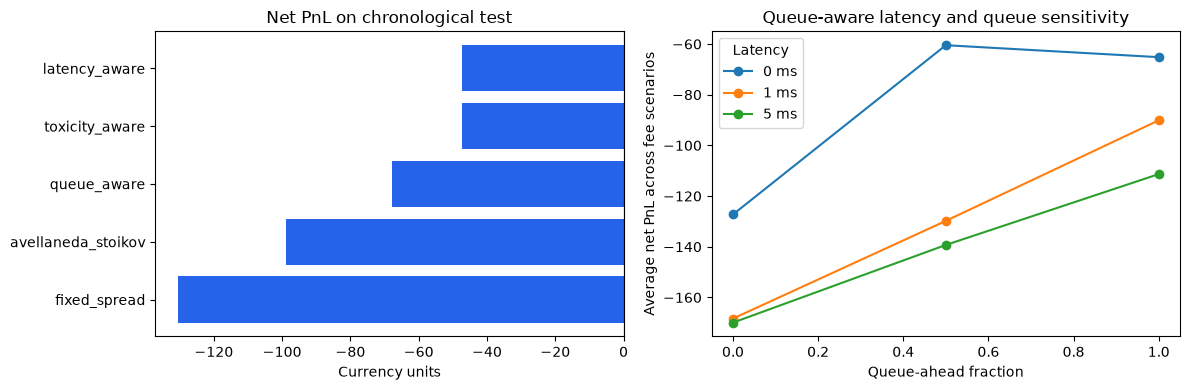

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ordered = comparison.sort_values('net_pnl')
axes[0].barh(ordered['strategy'], ordered['net_pnl'], color='#2563eb')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Net PnL on chronological test')
axes[0].set_xlabel('Currency units')
queue_view = sensitivity[sensitivity['strategy'].eq('queue_aware')].groupby(['latency_ns', 'queue_ahead_fraction'], as_index=False)['net_pnl'].mean()
for latency, frame in queue_view.groupby('latency_ns'):
    axes[1].plot(frame['queue_ahead_fraction'], frame['net_pnl'], marker='o', label=f'{latency / 1e6:g} ms')
axes[1].set_title('Queue-aware latency and queue sensitivity')
axes[1].set_xlabel('Queue-ahead fraction')
axes[1].set_ylabel('Average net PnL across fee scenarios')
axes[1].legend(title='Latency')
fig.tight_layout()
plt.show()

### Validation choice

In [6]:
validation.sort_values('queue_ahead_fraction').reset_index(drop=True)

,queue_ahead_fraction,net_pnl,risk_score
0,0.0,12.949074,0.219476
1,0.5,-31.740610,-0.577102
2,1.0,15.671772,0.474902


## Takeaways

1. Data integrity, chronological separation, and independent cash-ledger reconciliation are enforced before interpreting PnL.
2. Queue position, latency, and fees are exposed as sensitivities rather than hidden simulator constants.
3. Negative and unstable results remain visible. The sample is a pipeline demonstration, and the next research requirement is licensed multi-session data with true receive timestamps.